# Titanic Survival Prediction: EDA, Feature Engineering and Machine Learning

## Overview

This notebook focuses on predicting passenger survival in the Titanic dataset using a machine learning classification approach. The workflow includes data understanding, exploratory data analysis, feature engineering, preprocessing, model training, and prediction.

---

## 1. Data Loading and Understanding

The Titanic dataset was divided into:

* **Training Dataset**: Contains passenger information along with the survival label.
* **Testing Dataset**: Contains unseen passenger information used for final predictions.

The dataset contains different types of features:

* Numerical features: Age, Fare, PassengerId
* Categorical features: Survived, Pclass, Sex, Embarked, SibSp, Parch
* Mixed features: Name, Ticket, Cabin

Initial analysis was performed using dataset information, statistical summaries, and sample observations.

---

# 2. Exploratory Data Analysis (EDA)

EDA was performed to understand the structure, distribution, and relationship between different features.

## Age Analysis

* Age contains missing values, which were handled during preprocessing.
* The age distribution was analyzed using histograms and box plots.
* Age was approximately normally distributed.

## Fare Analysis

* Fare distribution was analyzed.
* The feature was positively skewed due to some passengers paying significantly higher fares.
* Outliers were identified through visualization.

## Survival Analysis

Feature relationships with survival were explored.

Key observations:

* Female passengers had a higher survival probability compared to male passengers.
* First-class passengers had significantly higher survival chances compared to lower classes.
* Family size influenced survival probability.

---

# 3. Feature Engineering

New meaningful features were created from existing columns.

## Individual Fare

A new feature was created to represent fare per individual passenger:

```
individual_fare = Fare / (SibSp + Parch + 1)
```

This helps remove the effect of shared family tickets.

---

## Family Size

Created a new feature:

```
family_size = SibSp + Parch + 1
```

This represents the total number of family members travelling together.

---

## Family Type

Passengers were categorized into:

* Alone
* Small family
* Large family

These categories were converted into numerical values for machine learning.

---

## Gender Encoding

The Sex column was transformed:

```
male → 0
female → 1
```

---

## Embarked Encoding

The Embarked feature was converted:

```
S → 0
C → 1
Q → 2
```

---

## IsAlone Feature

Created a binary feature:

```
IsAlone = 1  → Passenger travelled alone
IsAlone = 0  → Passenger travelled with family
```

---

## Title Extraction

Passenger titles were extracted from the Name column.

Examples:

* Mr
* Mrs
* Miss
* Master

Rare titles such as Doctor, Reverend, Captain, etc. were grouped into a single category:

```
Rare
```

Titles were converted into numerical values because machine learning algorithms cannot process text directly.

---

# 4. Data Preprocessing

The following preprocessing steps were performed:

* Missing Age values were filled using median age.
* Missing Fare values were filled using median fare.
* Missing Embarked values were filled using the most frequent value.
* Categorical features were converted into numerical representations.

The same preprocessing steps were applied to both training and testing datasets to maintain consistency.

---

# 5. Model Building

A Logistic Regression model was selected for this binary classification problem.

Features used:

* Pclass
* Female
* Age
* Fare
* Embarked
* Family Size
* IsAlone
* Title

The dataset was split into training and validation sets using:

* Test size: 20%
* Random state: 10

The model was trained on the training data and evaluated using accuracy score.

---

# 6. Prediction and Submission

After training, the model was used to predict survival outcomes for the test dataset.

The predictions were combined with PassengerId and exported as:

```
submission.csv
```

---

# Key Learning

A major learning from this project was understanding the importance of maintaining the same preprocessing pipeline for training and testing data.

Any feature engineering, encoding, or missing value handling performed on training data must also be applied identically to unseen data before making predictions.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
test_df = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
train_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

In [4]:
train_df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [5]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Column Types

- **Numerical** - Age,Fare,PassengerId
- **Categorical** - Survived, Pclass, Sex, SibSp, Parch,Embarked
- **Mixed** - Name, Ticket, Cabin

### Summary of the column `Age`
- 19% of the values are the null values.
- Age is normally distributed


In [7]:
train_df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

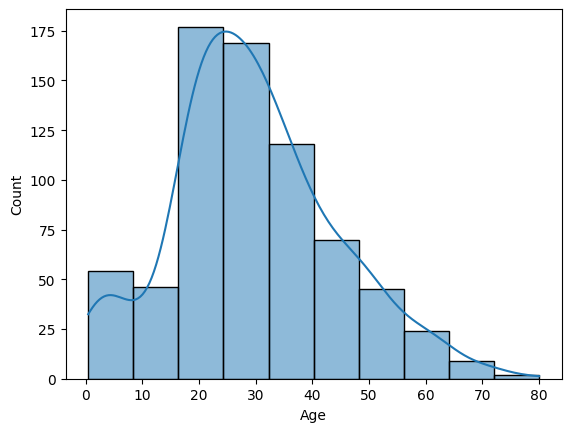

In [8]:
sns.histplot(train_df['Age'], kde= 'True', bins= 10)

<Axes: >

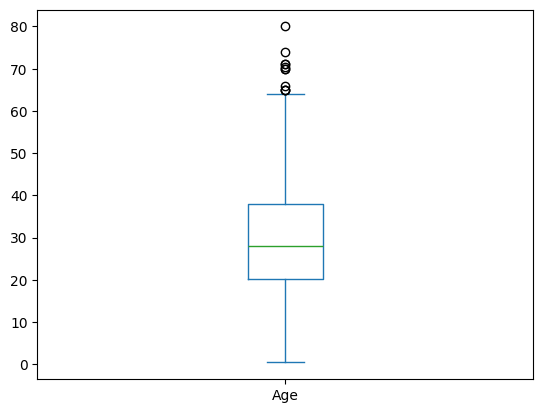

In [9]:
train_df['Age'].plot(kind='box')

In [10]:
train_df['Age'].isnull().sum()/len(train_df['Age'])

np.float64(0.19865319865319866)

### Fare
- The fare is depicted as per the family, these are not the indivisual fare.
- Data is positively skewed.
- May be we have to create new column which could depict the indivisual fare insted of the family fare.
  

In [11]:
train_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

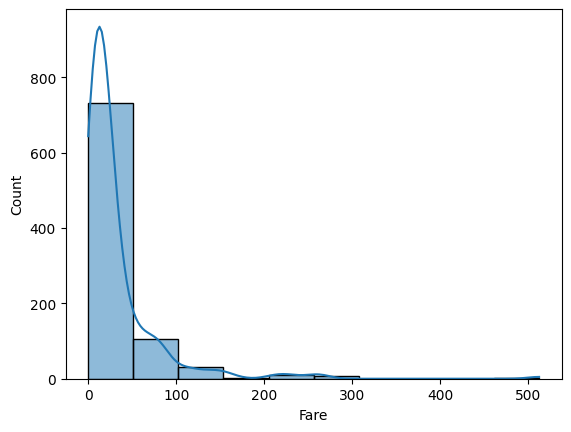

In [12]:
sns.histplot(train_df['Fare'], bins= 10, kde= 'True')

In [13]:
train_df['Fare'].skew()

np.float64(4.787316519674893)

<Axes: ylabel='Fare'>

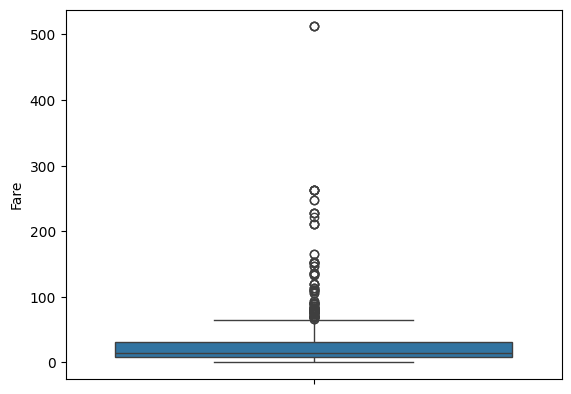

In [14]:
sns.boxplot(train_df['Fare'])

In [15]:
train_df[train_df['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


### Now lets compare the multiple columns with each other

In [16]:
train_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: ylabel='count'>

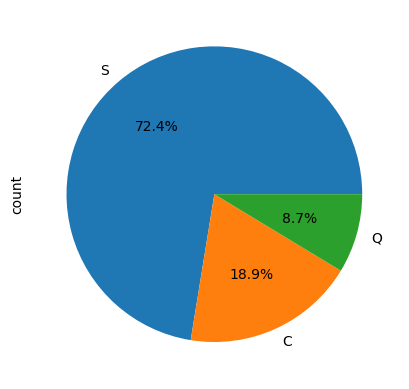

In [17]:
train_df['Embarked'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='Pclass', ylabel='Survived'>

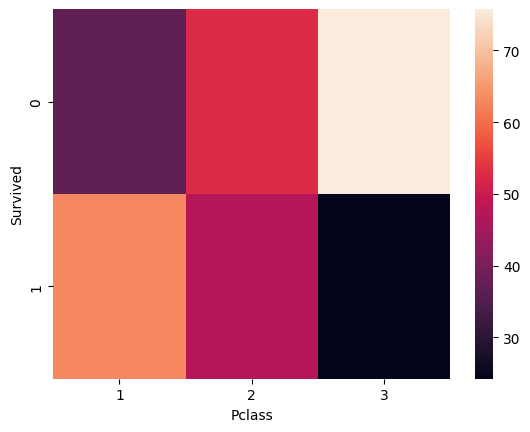

In [18]:
sns.heatmap(pd.crosstab(train_df['Survived'],train_df['Pclass'],normalize='columns')*100)

### The odds of surviving is way higher in the Pclass 1

In [19]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [20]:
pd.crosstab(train_df['Survived'],train_df['Sex'],normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [21]:
pd.crosstab(train_df['Sex'],train_df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [22]:
pd.crosstab(train_df['Pclass'],train_df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


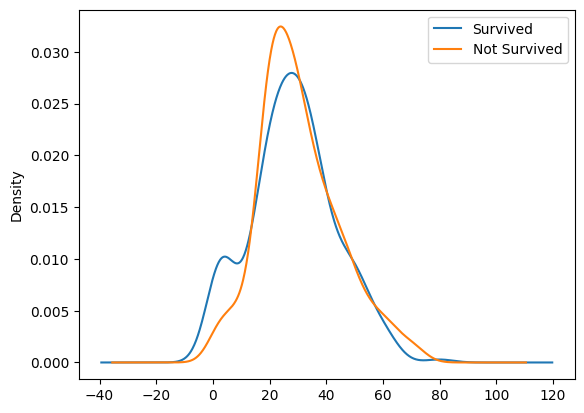

In [23]:
# survived and age

train_df[train_df['Survived'] == 1]['Age'].plot(kind='kde',label='Survived')
train_df[train_df['Survived'] == 0]['Age'].plot(kind='kde',label='Not Survived')

plt.legend()
plt.show()

In [24]:
train_df[train_df['Pclass'] == 1]['Age'].mean()

np.float64(38.233440860215055)

### Feature Enginnering


In [25]:
train_df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [26]:
train_df['individual_fare'] = train_df['Fare']/(train_df['SibSp'] + train_df['Parch'] + 1)

<Axes: >

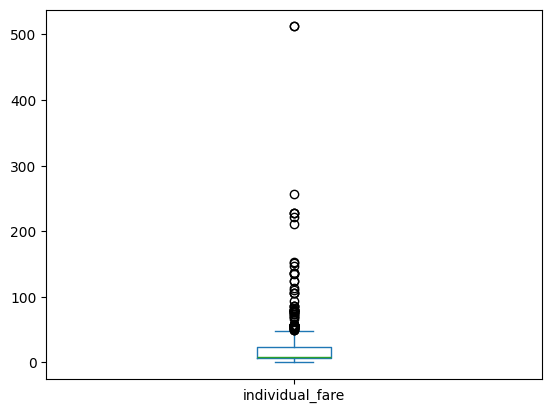

In [27]:
train_df['individual_fare'].plot(kind='box')

In [28]:
train_df[['individual_fare','Fare']].describe()

,individual_fare,Fare
count,891.000000,891.000000
mean,19.916375,32.204208
std,35.841257,49.693429
min,0.000000,0.000000
25%,7.250000,7.910400
50%,8.300000,14.454200
75%,23.666667,31.000000
max,512.329200,512.329200


In [29]:
train_df['family_size'] = train_df['SibSp'] + train_df['Parch'] + 1

In [30]:
# family_type
# 1 -> alone
# 2-4 -> small
# >5 -> large

def transform_family_size(num):

  if num == 1:
    return 'alone'
  elif num>1 and num <5:
    return "small"
  else:
    return "large"

In [31]:
train_df['family_type'] = train_df['family_size'].apply(transform_family_size)
train_df['family_type']

0      small
1      small
2      alone
3      small
4      alone
       ...  
886    alone
887    alone
888    small
889    alone
890    alone
Name: family_type, Length: 891, dtype: object

In [32]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000,1,alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000,1,alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250,4,small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000,1,alone


In [33]:
pd.crosstab(train_df['Survived'],train_df['family_type'],normalize='columns')*100

family_type,alone,large,small
Survived,,,
0,69.646182,83.870968,42.123288
1,30.353818,16.129032,57.876712


In [34]:
train_df



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000,1,alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000,1,alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250,4,small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000,1,alone


In [35]:

train_df['family_type'] = train_df['family_type'].str.strip().str.lower()
train_df['family_type'] = train_df['family_type'].map({'alone': 0, 'small': 1, 'large': 2})



In [36]:
train_df.rename(columns={'Sex':'Female'}, inplace=True)
train_df['Female'] = train_df['Female'].str.strip().str.lower()
train_df['Female'] = train_df['Female'].map({'male':0, 'female':1})
train_df['Female']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Female, Length: 891, dtype: int64

In [37]:
train_df['Embarked'] = train_df['Embarked'].str.strip().str.upper()
train_df['Embarked'] = train_df['Embarked'].map({'S':0, 'C':1, 'Q':2})
train_df['Embarked']

0      0.0
1      1.0
2      0.0
3      0.0
4      0.0
      ... 
886    0.0
887    0.0
888    0.0
889    1.0
890    2.0
Name: Embarked, Length: 891, dtype: float64

In [38]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())




In [39]:
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

In [40]:
train_df.sample(5)


,PassengerId,Survived,Pclass,Name,Female,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
449,450,1,1,"Peuchen, Major. Arthur Godfrey",0,52.0,0,0,113786,30.5000,C104,0.0,30.500000,1,0
373,374,0,1,"Ringhini, Mr. Sante",0,22.0,0,0,PC 17760,135.6333,NaN,1.0,135.633300,1,0
13,14,0,3,"Andersson, Mr. Anders Johan",0,39.0,1,5,347082,31.2750,NaN,0.0,4.467857,7,2
804,805,1,3,"Hedman, Mr. Oskar Arvid",0,27.0,0,0,347089,6.9750,NaN,0.0,6.975000,1,0
636,637,0,3,"Leinonen, Mr. Antti Gustaf",0,32.0,0,0,STON/O 2. 3101292,7.9250,NaN,0.0,7.925000,1,0


In [41]:
train_df['Embarked'].isnull().sum()
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [42]:
train_df['Embarked'].isnull().sum()

np.int64(0)

In [43]:
train_df['IsAlone'] = (train_df['family_size'] == 1).astype(int)

In [44]:
train_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Mlle','Ms'],'Miss').replace('Mme','Mrs')

In [45]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Female,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0,3.62500,2,1,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0,35.64165,2,1,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,7.92500,1,0,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0.0,26.55000,2,1,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0.0,8.05000,1,0,1,Mr


In [46]:
train_df["Title"] = train_df["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
     "Major", "Rev", "Sir", "Jonkheer", "Dona"],
    "Rare"
)

train_df["Title"] = train_df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})




In [47]:
title_map = {
    "Mr": 0,
    "Miss": 1,
    "Mrs": 2,
    "Master": 3,
    "Rare": 4
}

train_df["Title"] = train_df["Title"].map(title_map)

In [48]:
print(train_df["Title"].isnull().sum())

0


In [49]:
test_df["Female"] = (test_df["Sex"] == "female").astype(int)

In [50]:
test_df["family_size"] = test_df["SibSp"] + test_df["Parch"] + 1

In [51]:
test_df["IsAlone"] = (test_df["family_size"] == 1).astype(int)

In [52]:
test_df["Title"] = test_df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

In [53]:
embarked_map = {
    "S": 0,
    "C": 1,
    "Q": 2
}

In [54]:
test_df["Embarked"] = test_df["Embarked"].map(embarked_map)

In [55]:
test_df["Age"] = test_df["Age"].fillna(train_df["Age"].median())
test_df["Fare"] = test_df["Fare"].fillna(train_df["Fare"].median())

In [56]:
test_df["Title"] = test_df["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
     "Major", "Rev", "Sir", "Jonkheer", "Dona"],
    "Rare"
)

test_df["Title"] = test_df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

title_map = {
    "Mr": 0,
    "Miss": 1,
    "Mrs": 2,
    "Master": 3,
    "Rare": 4
}

test_df["Title"] = test_df["Title"].map(title_map)

In [57]:
print(test_df["Title"].head())
print(test_df["Title"].dtype)
print(test_df["Title"].isnull().sum())

0    0
1    2
2    0
3    0
4    2
Name: Title, dtype: int64
int64
0


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = [
    'Pclass',
    'Female',
    'Age',
    'Fare',
    'Embarked',
    'family_size',
    'IsAlone',
    'Title' 
]
X = train_df[features]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))


Validation Accuracy: 0.8435754189944135


In [59]:
test_X = test_df[features]
test_pred = model.predict(test_X)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_pred
})
submission.to_csv('submission.csv', index=False)

In [60]:
# print(train_df.columns.tolist())
# print(X.isnull().sum())
# print(test_df.columns.tolist())
print(test_df["Title"].head())
print(test_df["Title"].dtype)

0    0
1    2
2    0
3    0
4    2
Name: Title, dtype: int64
int64


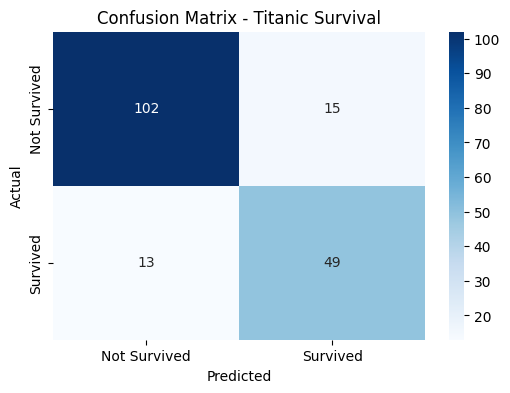

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       117
           1       0.77      0.79      0.78        62

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [61]:
from sklearn.metrics import confusion_matrix, classification_report

# Example: assuming you already have y_val (true labels) and y_pred (model predictions)
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Titanic Survival')
plt.show()

# Optional: print classification report for more detail
print(classification_report(y_val, y_pred))